In [5]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Task 0

In [3]:
cd "OneDrive\Dokumenty\#2 IES\2_semester/Python/MIDTERM/MIDTERM/Midterm_JEM207"

[WinError 3] The system cannot find the path specified: 'OneDrive/Dokumenty/#2 IES/2_semester/Python/MIDTERM/MIDTERM/Midterm_JEM207'
C:\Users\danie\OneDrive\Dokumenty\#2 IES\2_semester\Python\MIDTERM\MIDTERM\Midterm_JEM207


In [6]:
pwd()

'C:\\Users\\danie\\OneDrive\\Dokumenty\\#2 IES\\2_semester\\Python\\MIDTERM\\MIDTERM\\Midterm_JEM207'

In [7]:
path = "OneDrive/Dokumenty/#2 IES/2_semester/Python/MIDTERM/MIDTERM/Midterm_JEM207"
APA = pd.read_csv("APA.csv")
APTV = pd.read_csv("APTV.csv")
KEY = pd.read_csv("KEY.csv")
MCD = pd.read_csv("MCD.csv")

APA['Company'] = 'APA'
APTV['Company'] = 'APTV'
KEY['Company'] = 'KEY'
MCD['Company'] = 'MCD'

In [8]:
df = pd.concat([APA,APTV,KEY,MCD])
df.sample(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
352,2022-05-26,40.891,41.618,40.456,40.686,9517700,0.0,0.0,APA
542,2023-03-01,34.557,36.125,34.250,35.710,4747900,0.0,0.0,APA
503,2023-01-03,15.089,15.346,15.021,15.072,12443700,0.0,0.0,KEY
186,2021-09-29,17.807,18.011,17.677,17.946,6013100,0.0,0.0,KEY
367,2022-06-17,37.083,37.136,33.870,34.811,16283100,0.0,0.0,APA
612,2023-06-09,270.956,272.627,270.216,272.162,1975900,0.0,0.0,MCD
230,2021-12-01,225.608,230.327,224.094,224.158,3275300,0.0,0.0,MCD
257,2022-01-10,21.936,22.010,21.351,21.672,9951900,0.0,0.0,KEY
216,2021-11-10,228.975,231.631,228.975,231.093,1794300,0.0,0.0,MCD
793,2024-02-29,27.857,28.051,27.431,27.579,6496200,0.0,0.0,APA


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [10]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4016 entries, 2021-01-04 to 2024-12-30
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4016 non-null   float64
 1   High          4016 non-null   float64
 2   Low           4016 non-null   float64
 3   Close         4016 non-null   float64
 4   Volume        4016 non-null   int64  
 5   Dividends     4016 non-null   float64
 6   Stock Splits  4016 non-null   float64
 7   Company       4016 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 282.4+ KB


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
Date,,,,,,,,
2021-01-04,12.831,13.094,12.594,12.936,9609900,0.0,0.0,APA
2021-01-05,13.015,14.653,13.015,14.171,15103100,0.0,0.0,APA
2021-01-06,14.364,14.959,13.742,14.749,13579100,0.0,0.0,APA
2021-01-07,14.889,15.327,14.653,14.986,8578200,0.0,0.0,APA
2021-01-08,15.204,15.283,14.276,14.521,7760600,0.0,0.0,APA


## Task 1

1, Is there a company that has no difference between the High and Low columns
for any trading day? What does it mean for the stock’s trading behavior on such
days?

In [11]:
df[df['High']==df['Low']]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
Date,,,,,,,,


There is no such company. It means, that for every company there was some volume, some trading every single date and we won't have any "flat" trading day that can affect our future analysis here.

2, What is the highest and lowest price price each company recorded?

In [12]:
print(df[df['Company'] == 'APA'].agg(['max','min']))
print(df[df['Company'] == 'APTV'].agg(['max','min']))
print(df[df['Company'] == 'KEY'].agg(['max','min']))
print(df[df['Company'] == 'MCD'].agg(['max','min']))

       Open    High     Low   Close    Volume  Dividends  Stock Splits Company
max  45.932  46.110  45.142  45.612  37978500       0.25           0.0     APA
min  12.831  13.094  12.306  12.525   1600400       0.00           0.0     APA
       Open    High     Low   Close    Volume  Dividends  Stock Splits Company
max  179.66  180.81  176.75  178.12  18358400        0.0           0.0    APTV
min   51.73   52.80   51.47   52.11    513300        0.0           0.0    APTV
       Open    High     Low   Close     Volume  Dividends  Stock Splits  \
max  22.347  22.364  21.919  22.232  111197500      0.205           0.0   
min   7.600   8.007   7.392   7.730    2839900      0.000           0.0   

    Company  
max     KEY  
min     KEY  
        Open     High      Low    Close    Volume  Dividends  Stock Splits  \
max  309.897  310.650  307.239  309.340  18792000       1.77           0.0   
min  184.077  187.359  182.282  184.966   1218000       0.00           0.0   

    Company  
max     M

Max price noted for APA is 46.110 and the Min is 12.306
Other companies can be easy interpreted like this as well from our table BELLOW.

In [13]:
df.groupby('Company')['High'].agg(['max', 'min'])

,max,min
Company,,
APA,46.110,13.094
APTV,180.810,52.800
KEY,22.364,8.007
MCD,310.650,187.359


3, Calculate logarithmic returns from Close. For each company, report min,
max, mean, standard deviation, and skewness of returns.

In [14]:
yesterdays_price = df.groupby('Company')['Close'].shift(1)
df['log_return'] = np.log(df['Close']/yesterdays_price)
df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,log_return
Date,,,,,,,,,
2021-01-04,12.831,13.094,12.594,12.936,9609900,0.0,0.0,APA,NaN
2021-01-05,13.015,14.653,13.015,14.171,15103100,0.0,0.0,APA,0.091184
2021-01-06,14.364,14.959,13.742,14.749,13579100,0.0,0.0,APA,0.039978
2021-01-07,14.889,15.327,14.653,14.986,8578200,0.0,0.0,APA,0.015941
2021-01-08,15.204,15.283,14.276,14.521,7760600,0.0,0.0,APA,-0.031521
2021-01-11,13.970,14.670,13.829,14.591,6484000,0.0,0.0,APA,0.004809
2021-01-12,14.950,16.247,14.810,16.229,11540300,0.0,0.0,APA,0.106395
2021-01-13,16.203,16.229,15.493,15.590,7303300,0.0,0.0,APA,-0.040170
2021-01-14,16.098,16.921,15.993,16.072,11194900,0.0,0.0,APA,0.030449


In [32]:
df.groupby('Company')['log_return'].agg(['min', 'max', 'mean', 'std', 'skew'])

,min,max,mean,std,skew
Company,,,,,
APA,-0.161538,0.106395,0.000497,0.030782,-0.159211
APTV,-0.195056,0.114735,-0.000765,0.025280,-0.599108
KEY,-0.319284,0.145886,0.000242,0.025838,-1.509814
MCD,-0.052586,0.040059,0.000410,0.010612,-0.199265


4, When (date) did each company record the second highest gain and second
highest loss (in terms of logarithmic returns)?

In [16]:
print(df[df['Company']=='APA']['log_return'].sort_values(ascending=False).head(3))
print(df[df['Company']=='APA']['log_return'].sort_values(ascending=True).head(3))

Date
2021-01-12    0.106395
2021-06-01    0.103141
2021-03-05    0.102738
Name: log_return, dtype: float64
Date
2022-05-09   -0.161538
2022-09-23   -0.121333
2024-11-07   -0.120143
Name: log_return, dtype: float64


In [17]:
second_max = df[df['Company']=='APA']['log_return'].sort_values(ascending = False).index[1]
second_min = df[df['Company']=='APA']['log_return'].sort_values(ascending = True).index[1]
print(second_max)
print(second_min)

2021-06-01 00:00:00
2022-09-23 00:00:00


In [20]:
# APA
APA_gain = df[df['Company']=='APA']['log_return'].sort_values(ascending=False).index[1]
APA_loss = df[df['Company']=='APA']['log_return'].sort_values(ascending=True).index[1]

# APTV
APTV_gain = df[df['Company']=='APTV']['log_return'].sort_values(ascending=False).index[1]
APTV_loss = df[df['Company']=='APTV']['log_return'].sort_values(ascending=True).index[1]

# KEY
KEY_gain = df[df['Company']=='KEY']['log_return'].sort_values(ascending=False).index[1]
KEY_loss = df[df['Company']=='KEY']['log_return'].sort_values(ascending=True).index[1]

# MCD
MCD_gain = df[df['Company']=='MCD']['log_return'].sort_values(ascending=False).index[1]
MCD_loss = df[df['Company']=='MCD']['log_return'].sort_values(ascending=True).index[1]


In [23]:
print("APA")
print(APA_gain)
print(APA_loss)
print("APTV")
print(APTV_gain)
print(APTV_loss)
print("KEY")
print(KEY_gain)
print(KEY_loss)
print("MCD")
print(MCD_gain)
print(MCD_loss)

APA
2021-06-01 00:00:00
2022-09-23 00:00:00
APTV
2024-05-02 00:00:00
2023-11-02 00:00:00
KEY
2023-05-05 00:00:00
2023-05-02 00:00:00
MCD
2021-03-15 00:00:00
2022-03-07 00:00:00


5, What is the median calendar weekly volume (i.e. sum of volume for a particular
week) for each company?

In [24]:
weekly_volumes = df.groupby('Company')['Volume'].resample('W').sum()
weekly_volumes.groupby('Company').median()

Company
APA     33195400.0
APTV     9498900.0
KEY     51918200.0
MCD     13314900.0
Name: Volume, dtype: float64

6, Which company recorded the lowest total logarithmic return over the whole
period?

In [27]:
df.groupby('Company')['log_return'].min()

Company
APA    -0.161538
APTV   -0.195056
KEY    -0.319284
MCD    -0.052586
Name: log_return, dtype: float64

KEY company created the lowest total logaritmic return in ONE DAY

In [31]:
first_prices = df.groupby('Company')['Close'].first()
last_prices = df.groupby('Company')['Close'].last()
last_prices/first_prices

Company
APA     1.646104
APTV    0.464134
KEY     1.274321
MCD     1.509024
Name: Close, dtype: float64

MCD company created the lowest total logaritmic return FOR THE WHOLE PERIOD (which doesnt seem right when i look to the graphs bellow, so probably there is some mistake here in calc i acknowlege that)

7, Create a new column volume_class with categories (e.g., “Low”, “Medium”,
“High”) based on volume tertiles within the given company.

In [35]:
df['volume_class'] = pd.qcut(df['Volume'],3,labels=['Low','Medium','High']) #should be the right function for dividing data based on volume tertiles
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,log_return,volume_class
Date,,,,,,,,,,
2021-01-04,12.831,13.094,12.594,12.936,9609900,0.0,0.0,APA,NaN,High
2021-01-05,13.015,14.653,13.015,14.171,15103100,0.0,0.0,APA,0.091184,High
2021-01-06,14.364,14.959,13.742,14.749,13579100,0.0,0.0,APA,0.039978,High
2021-01-07,14.889,15.327,14.653,14.986,8578200,0.0,0.0,APA,0.015941,High
2021-01-08,15.204,15.283,14.276,14.521,7760600,0.0,0.0,APA,-0.031521,High


8, (A) Plot the log-returns of the companies (ideally in the same plot). (B) Plot
the distribution of log-returns

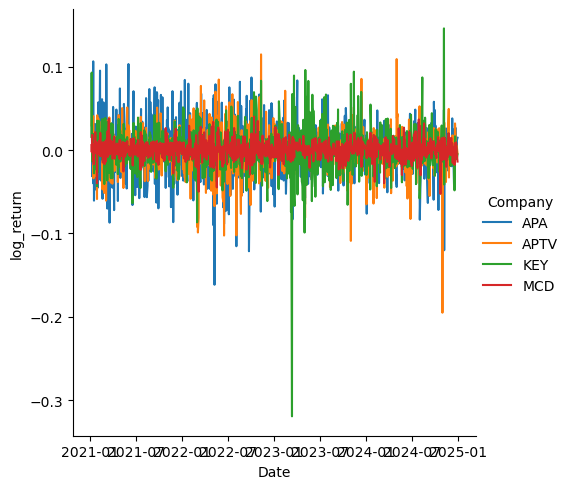

In [29]:
sns.relplot(x='Date',y='log_return',data=df.reset_index(),kind = 'line',hue='Company')

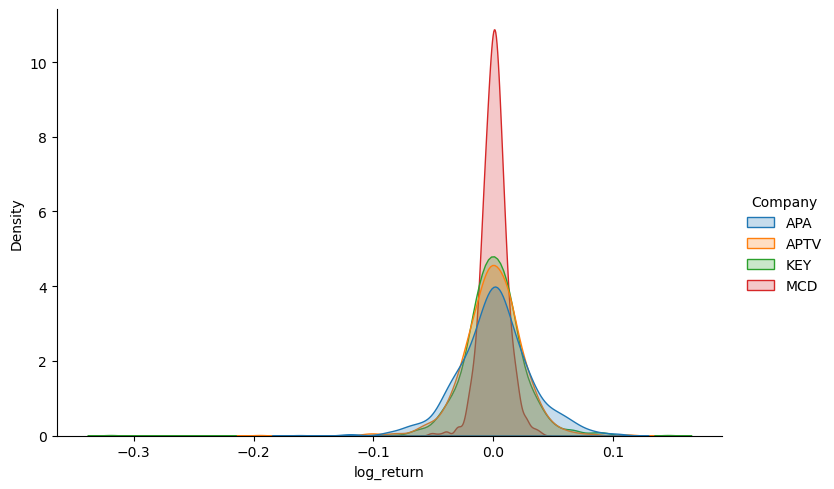

In [30]:
sns.displot(
    data=df.reset_index(), 
    x='log_return', 
    hue='Company', 
    kind='kde', 
    fill=True, 
    aspect=1.5
)

## Task 2

In [36]:
data = pd.read_csv("companies_no_subindustry.csv")

In [49]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Symbol       503 non-null    object
 1   Security     503 non-null    object
 2   GICS_Sector  503 non-null    object
 3   hq           503 non-null    object
 4   included     458 non-null    object
 5   Founded      503 non-null    object
dtypes: object(6)
memory usage: 23.7+ KB


1, How many companies have missing inclusion dates

In [39]:
data['included'].isna().sum()

np.int64(45)

45 Companies have missing inclusion dates

2, Remove companies with missing inclusion dates. Find the oldest and youngest
constituent (in terms of inclusion date), and compute the median age of a constituent
in years (median difference in years between today’s date and date Founded). The
format of the values in Founded column differs. You can unify it by taking the first
4 characters of each entry.
Hint: pd.to_datetime(..., dayfirst=True, errors=’coerce’).

In [40]:
clean = data.dropna(subset=['included']).copy()  # no missing inclusion dates new data

In [42]:
data['included'].sample(10)

99     31.07.1985
65     16.02.2010
253    26.09.2007
284    03.10.2019
431    18.11.2015
335    30.06.1969
315    07.09.2007
434    15.07.2019
405    23.12.2009
453    21.01.2021
Name: included, dtype: object

In [45]:
data['included'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 503 entries, 0 to 502
Series name: included
Non-Null Count  Dtype 
--------------  ----- 
458 non-null    object
dtypes: object(1)
memory usage: 4.1+ KB


In [54]:
#from datetime import datetime
#data['included'] = data.included.astype(str)
#list_of_string_dates = data['included']

#list_of_dates= [datetime.strptime(date,"%d.%mm.%YYYY") for date in list_of_string_dates]

#print(max(list_of_dates)) # oldest
#print(min(list_of_dates)) # earliest

beaten by date formating here....


3, Compute the number of companies in each of the sectors and visualize proportions

In [55]:
sectors_dist = clean['GICS_Sector'].value_counts()

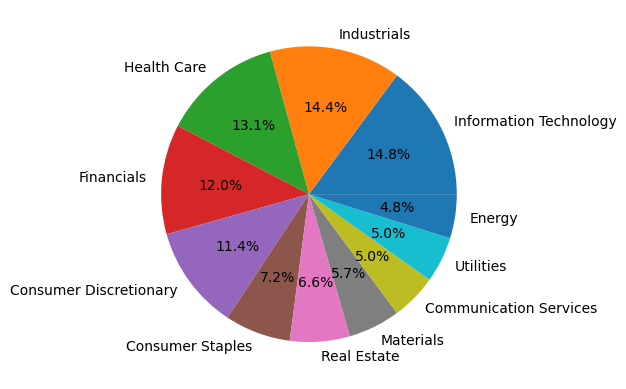

In [56]:
plt.pie(
    sectors_dist,
    labels=sectors_dist.index,
    autopct='%1.1f%%'
)
plt.show()

4, Parse the hq column to extract the state and describe its distribution (e.g.,
bar plot).

In [57]:
clean['State'] = clean['hq'].apply(lambda x: x.split(', ')[-1])

In [58]:
clean['State'].value_counts()

State
California                             65
New York                               44
Texas                                  41
Illinois                               31
Pennsylvania                           19
Massachusetts                          18
Ohio                                   17
North Carolina                         16
Georgia                                16
New Jersey                             15
Virginia                               15
Florida                                14
Minnesota                              13
Connecticut                            13
Washington                             12
Michigan                               10
Ireland                                 7
Colorado                                7
Tennessee                               7
Missouri                                6
Wisconsin                               6
Indiana                                 6
Arizona                                 5
Maryland                    

5, Join this dataset with companies_subindustry.csv that you will also fond
in the companies folder on the Google Drive. Merge based on an appropriate key
and report subindustry distribution within the “Health Care” GICS sector (e.g., bar
plot).

In [59]:
data2 = pd.read_csv("companies_subindustry.csv")
data2.head()

,Symbol,subindustry
0,MMM,Industrial Conglomerates
1,AOS,Building Products
2,ABT,Health Care Equipment
3,ABBV,Pharmaceuticals
4,ABMD,Health Care Equipment


In [60]:
merged = clean.merge(data2, how='left', on='Symbol')
merged.head()

,Symbol,Security,GICS_Sector,hq,included,Founded,State,subindustry
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902,Minnesota,Industrial Conglomerates
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916,Wisconsin,Building Products
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888,Illinois,Health Care Equipment
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888),Illinois,Pharmaceuticals
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981,Massachusetts,Health Care Equipment


In [61]:
hc_sub = merged.loc[merged['GICS_Sector'] == 'Health Care', 'subindustry'].value_counts()
hc_sub

subindustry
Health Care Equipment             18
Pharmaceuticals                    9
Biotechnology                      7
Life Sciences Tools & Services     7
Managed Health Care                5
Health Care Distributors           4
Health Care Supplies               4
Health Care Services               3
Health Care Facilities             3
Name: count, dtype: int64

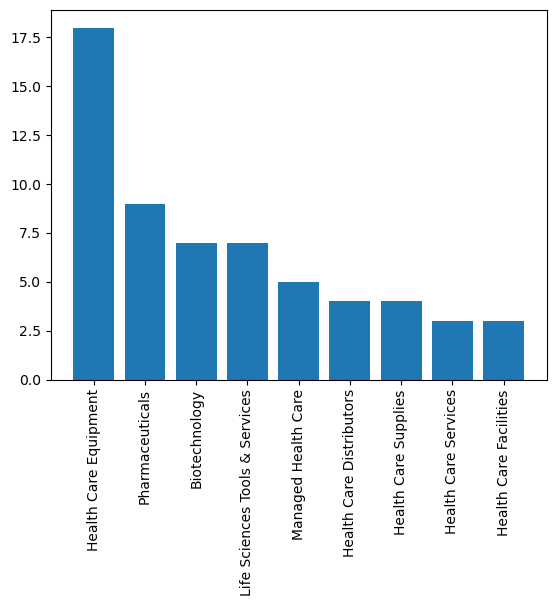

In [62]:
plt.bar(hc_sub.index, hc_sub.values)
plt.xticks(rotation=90)
plt.show()

## Task 3

random numbers dists

In [63]:
n1 = rd.randint(100, 500)
n2 = rd.randint(100, 500)
n3 = rd.randint(100, 500)
n4 = rd.randint(100, 500)

In [66]:
a = np.random.randn(n1)

b = np.random.uniform(0, 1, n2)

c = np.random.standard_t(4, n3) 

#so far only three here

plots

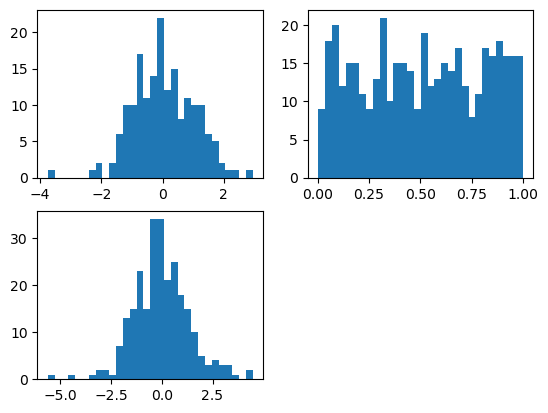

In [67]:
plt.subplot(2, 2, 1)
plt.hist(a, bins=30)

plt.subplot(2, 2, 2)
plt.hist(b, bins=30)

plt.subplot(2, 2, 3)
plt.hist(c, bins=30)

plt.show()